# MODFLOW 6: modelo GWF.

<p xmlns:cc="http://creativecommons.org/ns#" xmlns:dct="http://purl.org/dc/terms/"><a property="dct:title" rel="cc:attributionURL" href="https://github.com/luiggix/RTWMA/">MODFLOW 6: modelo GWF</a> by <b>Luis M. de la Cruz Salas (2025)</b> is licensed under <a href="http://creativecommons.org/licenses/by-sa/4.0/?ref=chooser-v1" target="_blank" rel="license noopener noreferrer" style="display:inline-block;">Attribution-ShareAlike 4.0 International<img style="height:22px!important;margin-left:3px;vertical-align:text-bottom;" src="https://mirrors.creativecommons.org/presskit/icons/cc.svg?ref=chooser-v1"><img style="height:22px!important;margin-left:3px;vertical-align:text-bottom;" src="https://mirrors.creativecommons.org/presskit/icons/by.svg?ref=chooser-v1"><img style="height:22px!important;margin-left:3px;vertical-align:text-bottom;" src="https://mirrors.creativecommons.org/presskit/icons/sa.svg?ref=chooser-v1"></a>.</p> 

# Introducción.

El modelo GWF (*Groundwater Flow*) de MODFLOW 6 es un componente principal que simula el flujo del agua subterránea en medios porosos, como acuíferos. Este modelo resuelve la ecuación de flujo en tres dimensiones, permitiendo representar cómo el agua se mueve bajo tierra en función de las propiedades del subsuelo, las condiciones de frontera y las fuentes o sumideros, como recarga, pozos y ríos. El modelo GWF se define dentro de una simulación general y puede conectarse con otros modelos, como el de transporte de solutos (GWT) o modelos de flujo de superficie. Esto permite construir simulaciones integradas con diferentes procesos acoplados.

Un modelo GWF puede ser configurado por varios paquetes. Un paquete es la parte del modelo que se ocupa de un único aspecto de la simulación. 

## Objetivo.
En este documento se realiza una simulación de flujo en dos dimensiones, explicando paso a paso el proceso y describiendo los paquetes del modelo GWF que son usados. 

Se utilizan las herramientas de flopy para facilitar el pre y postprocesamiento de la información requerida por el simulador.

<div class="alert alert-block alert-info">

# Ejemplo: Simulación de flujo en 2D.

En este ejemplo se simula una distribución de carga hidráulica en un dominio rectangular de $10$ m $\times$ $10$ m con un espesor de $1$ m.  La carga va de $10$ m en el lado izquierdo a $5$ m lado derecho, formando un gradiente horizontal de flujo. Los lados superior e inferior del dominio son impermeables. No hay fuentes no sumideros.

</div>

## Paso 1. Configuración inicial.

<div class="alert alert-block alert-info">

* Haremos la configuración inicial de la simulación de manera similar al ejemplo 2 de la notebook [00_MF6_Intro.ipynb](00_MF6_Intro.ipynb). 

* En este caso agregaremos algunas opciones adicionales al solucionador IMS para ver el efecto que tiene en los archivos de entrada, particularmente en `flow.ims`, véase **Iterative Model Solution**, pp 225-231, en [2] y [ModflowIms doc](https://flopy.readthedocs.io/en/3.3.2/source/flopy.mf6.modflow.mfims.html). 

* El espacio de trabajo donde se escriben todos los archivos será la carpeta `sandbox2`.

* La simulación así como el modelo de flujo tendrán el nombre `flow`.

</div>

In [12]:
import flopy
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración inicial ---
model_name = "flow"
sim_ws = "./sandbox2"

sim = flopy.mf6.MFSimulation(
    sim_name = model_name,
#    exe_name = '../../bin/windows/mf6',
    exe_name = '../../bin/macosarm/mf6',
    sim_ws   = sim_ws
)

# --- Tiempos de simulación ---
tdis = flopy.mf6.ModflowTdis(
    sim,
    time_units = "DAYS",
    nper = 1,
    perioddata = [(1.0, 1, 1.0)],
)

# --- Solucionador numérico (IMS) ---
ims = flopy.mf6.ModflowIms(
    sim,
    print_option        = "SUMMARY",
    complexity          = "SIMPLE",
    outer_dvclose       = 1e-4,
    outer_maximum       = 50,
    under_relaxation    = "NONE",
    linear_acceleration = "CG",
    inner_maximum       = 30,
    inner_dvclose       = 1e-6,
)

# --- Modelo GWF ---
gwf = flopy.mf6.ModflowGwf(
    sim,
    modelname = model_name,
    model_nam_file = f"{model_name}.nam",
    save_flows = True
)

# --- Escribimos los archivos ---
sim.write_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model flow...
    writing model name file...


<div class="alert alert-block alert-info">

Revisa los archivos generados en la carpeta `sandbox2`, particularmente el `flow.ims`.

</div>

## Paso 2. Discretización espacial.

El dominio espacial de una simulación en MODFLOW 6 se divide en una rejilla de celdas y provee de  tres paquetes diferentes (véase Chapter 3. Spatial Discretization de [1]):

* **DIS**. Paquete para discretización estructurada.
* **DISV**. Paquete para discretización por vértices.
* **DISU**. Paquete para discretización NO estructurada.

Solo se puede usar un paquete de discretización en una simulación con GWF.

La información almacenada en los paquetes de discretización es usada durante la simulación por GWF para realizar varias acciones, por ejemplo:
* calcular la conductividad hidráulica entre celdas conectadas, 
* calcular los volúmenes de celda para los cálculos de almacenamiento,
* convertir los flujos de recarga y evapotranspiración, por ejemplo de las dimensiones de L/T a L$^3$/T.

Los paquetes de discretización:
* contienen información acerca de las celdas, como las elevaciones superior (`TOP`) e inferior (`BOTTOM`) de la celda y las dimensiones o áreas de la celda (en vista de planta). 
* definen la conectividad de las celdas, que describe cómo las celdas modelo están conectadas entre sí y las propiedades geométricas de las conexiones.
* En el paquete **DIS**, la conectividad de la celda se describe implícitamente por la estructura de la malla, las dimensiones de la celda en las direcciones de renglones y columnas, y las elevaciones de la parte superior e inferior de la celda.

La siguiente figura (tomada de [1]) muestra un ejemplo de una malla regular en tres dimensiones en donde se definen columnas, renglones y capas.

<img src="../figures/mesh_3D_mf6.png" width=400px hspace="5" vspace="5" style="float: left;"/>

* En este ejemplo tenemos 9 columnas (`NROW`), 5 renglones (`NCOL`) y 5 capas (`NLAY`).

* El tamaño horizontal del las celdas está definido por $\Delta r_i$ y $\Delta c_i$ (variables `DELR`$_i$ y  `DELC`$_i$). 

* Observa que $\Delta r_i$ se mide en la dirección de los renglones (en el eje $x$ en un sistema Cartesiano), es decir, mide el tamaño de la columna $i$-ésima. 

* Por otro lado, $\Delta c_i$ se mide en la dirección de las columnas (en el eje $y$), por lo que mide el tamaño del renglón $i$-ésimo

* Las capas se numeran empezando por la capa superior y hacia abajo. 

* Las elevaciones de las celdas se especifican en la variable `BOTM` (indica la parte inferior de cada capa). La elevación de la parte superior de la primera capa se debe especificar en la variable `TOP`.

* La información de las elevaciones se usa para calcular el espesor de las celdas.


<div class="alert alert-block alert-info">

* Para obtener el modelo del dominio rectangular requerido ($10$ m $\times$ $10$ m con un espesor de $1$ m.
* $10 \times 10 \times 1$ usamos los parámetros `nrow`, `ncol` y `nlay`.
* Debemos calcular `delr` y `delc` para obtener la longitud correcta del dominio: $10$ = `nrow` * `delc` y $10$ = `ncol` * `delr`.
* Los parámetros `top` y `botm` deben ser tales que `top - botm` $= 1$.

</div>

In [13]:
# --- Malla del modelo ---
nlay, nrow, ncol = 1, 20, 20
delr = 0.5
delc = 0.5
top  = 0.0
botm = -1.0

dis = flopy.mf6.ModflowGwfdis(
    gwf,
    length_units = "METERS",
    nlay = nlay,
    nrow = nrow,
    ncol = ncol,
    delr = delr,
    delc = delc,
    top  = top,
    botm = botm,
)

print(dis)
sim.write_simulation()

package_name = dis
filename = flow.dis
package_type = dis
model_or_simulation_package = model
model_name = flow

Block options
--------------------
length_units
{internal}
(meters)


Block dimensions
--------------------
nlay
{internal}
(1)

nrow
{internal}
(20)

ncol
{internal}
(20)


Block griddata
--------------------
delr
{constant 0.5}

delc
{constant 0.5}

top
{constant 0.0}

botm
{constant -1.0}



writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model flow...
    writing model name file...
    writing package dis...


<div class="alert alert-block alert-info">

* En la celda anterior se construye el objeto `dis` de la clase `flopy.mf6.ModflowGwfdis` para generar la información de la discretización espacial. Esta clase construye una discretiación de tipo DIS.

* El primer parámetro en esta construcción es el modelo al que esta discretización pertenece, en este caso `gwf`. Posteriormente se agregan todos los parámetros de la discretización.

* La celda anterior genera el archivo `flow.dis` con la información correspondiente a la discretización espacial, revisa este archivo en la carpeta `sandbox2`.

* Adicionalmente, el archivo `flow.nam` es modificado agregando la información del paquete DIS, deberías ver un bloque como el siguiente en ese archivo:

```
BEGIN packages
  DIS6  flow.dis  dis
END packages
```
</div>

## Paso 3. Condiciones iniciales.

El paquete encargado de definir las condiciones iniciales es IC (*Initial Conditions*). Se utiliza para asignar los valores iniciales de la carga hidráulica en todas las celdas activas del modelo al comenzar una simulación, especialmente importante cuando se trabaja con modelos transitorios. Se aplica al inicio del primer periodo de estrés y es obligatorio en el modelo GWF.

En simulaciones estacionarias, los valores iniciales no afectan los resultados finales, pero aún así son requeridos por MODFLOW 6. El modelo no podrá ejecutarse correctamente si no se proporciona este paquete.

<div class="alert alert-block alert-info">

* Usaremos la clase `flopy.mf6.ModflowGwfic` para crear el objeto `ic`. 
* El primer parámetro es el modelo GWF al que se le desean agregar las condiciones iniciales.
* El parámetro `strt` indica el valor de la condición inicial para la carga hidráulica. Puede ser un número escalar (mismo valor en todo el dominio) o un arreglo 2D o 3D para especificar la carga en cada celda.

En la siguiente celda se genera una condición inicial de carga hidráulica igual a $10$:

</div>

In [14]:
ic = flopy.mf6.ModflowGwfic(
    gwf,
    strt=10.0 
)

print(ic)
sim.write_simulation()

package_name = ic
filename = flow.ic
package_type = ic
model_or_simulation_package = model
model_name = flow

Block griddata
--------------------
strt
{constant 10.0}



writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model flow...
    writing model name file...
    writing package dis...
    writing package ic...


<div class="alert alert-block alert-info">

* La celda anterior genera el archivo `flow.ic` con la información para las condiciones iniciales.
* Adicionalmente se agrega la información de este paquete en el archivo `flow.nam`. Deberías obtener un bloque en ese archivo como el que sigue: 

```
BEGIN packages
  DIS6  flow.dis  dis
  IC6  flow.ic  ic
END packages
```

* Si se tiene un modelo con topografía variable y se desea usar la elevación superior como condición inicial, se podría hacer algo como:

```python
strt = top.copy()  # usar la elevación como nivel inicial
ic = flopy.mf6.ModflowGwfic(gwf, strt=strt)
```
</div>

## Paso 4. Condiciones de frontera.

In [15]:
chd_data = []
for row in range(nrow):
    chd_data.append([(0, row, 0), 10.0])
    chd_data.append([(0, row, ncol - 1), 5.0])

chd = flopy.mf6.ModflowGwfchd(
    gwf,
    stress_period_data=chd_data,
#    pname="CHD-1", # Cuando no se pone usa 'CHD_0', puede ser cualquier string
#    save_flows=True,
)

print(chd)
sim.write_simulation()

package_name = chd_0
filename = flow.chd
package_type = chd
model_or_simulation_package = model
model_name = flow

Block period
--------------------
stress_period_data
{internal}
(    cellid_layer  cellid_row  cellid_column  head
0              0           0              0  10.0
1              0           0             19   5.0
2              0           1              0  10.0
3              0           1             19   5.0
4              0           2              0  10.0
5              0           2             19   5.0
6              0           3              0  10.0
7              0           3             19   5.0
8              0           4              0  10.0
9              0           4             19   5.0
10             0           5              0  10.0
11             0           5             19   5.0
12             0           6              0  10.0
13             0           6             19   5.0
14             0           7              0  10.0
15             0    

## Paso 5. Propiedades hidráulicas.

In [16]:
npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    save_flows=True,
    icelltype=1,  # flujo en la cara superior
    k=1.0,        # conductividad hidráulica (constante)
)

print(npf)
sim.write_simulation()

package_name = npf
filename = flow.npf
package_type = npf
model_or_simulation_package = model
model_name = flow

Block options
--------------------
save_flows
{internal}
(True)


Block griddata
--------------------
icelltype
{constant 1}

k
{constant 1.0}



writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model flow...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package chd_0...
    writing package npf...


## Paso 6. Configuración de la salida.

In [17]:
head = flopy.mf6.ModflowGwfoc(
    gwf,
    budget_filerecord=f"{model_name}.cbc",
    head_filerecord=f"{model_name}.hds",
    saverecord=[("HEAD", "ALL")],
    printrecord=[("HEAD", "ALL")]
)

print(head)
sim.write_simulation()

package_name = oc
filename = flow.oc
package_type = oc
model_or_simulation_package = model
model_name = flow

Block options
--------------------
budget_filerecord
{internal}
([('flow.cbc',)])

head_filerecord
{internal}
([('flow.hds',)])


Block period
--------------------
saverecord
{internal}
([('HEAD', 'ALL', None)])

printrecord
{internal}
([('HEAD', 'ALL', None)])



writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model flow...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package chd_0...
    writing package npf...
    writing package oc...


## Paso 7. Ejecución de la simulación.

In [18]:
sim.run_simulation(silent=False)

FloPy is using the following executable to run the model: ../../../bin/macosarm/mf6
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.1 02/10/2025

        MODFLOW 6 compiled Feb 10 2025 17:05:58 with GCC version 13.3.0

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 
Government shall be held liable for any damages resulting from its 
authorized or unauthorized use. Also refer to the USGS Water 
Resources So

(True, [])

## Paso 8. Recuperación de los resultados.

In [19]:
headfile = f"{sim_ws}/{model_name}.hds"
hds = flopy.utils.HeadFile(headfile)
head = hds.get_data(mflay=0) # Solo se obtiene la capa 0, cuando no se pone
                             # ningún valor se obtienen todas las capas

grid = gwf.modelgrid

print("HEAD shape", head.shape)
print("HEAD type", type(head))
print("HEAD", head)

HEAD shape (20, 20)
HEAD type <class 'numpy.ndarray'>
HEAD [[10.          9.73684214  9.47368428  9.21052641  8.94736852  8.6842106
   8.42105267  8.15789473  7.89473679  7.63157887  7.36842097  7.10526308
   6.84210519  6.5789473   6.31578943  6.05263156  5.78947367  5.52631579
   5.2631579   5.        ]
 [10.          9.73684215  9.47368429  9.21052641  8.94736851  8.6842106
   8.42105267  8.15789473  7.89473679  7.63157885  7.36842095  7.10526308
   6.84210521  6.57894734  6.31578946  6.05263158  5.78947368  5.52631578
   5.26315789  5.        ]
 [10.          9.73684214  9.47368428  9.2105264   8.9473685   8.68421058
   8.42105265  8.15789472  7.8947368   7.63157888  7.36842097  7.10526308
   6.84210522  6.57894735  6.31578946  6.05263158  5.78947369  5.52631579
   5.26315789  5.        ]
 [10.          9.73684214  9.47368427  9.21052638  8.94736848  8.68421057
   8.42105264  8.15789471  7.8947368   7.63157891  7.36842101  7.10526311
   6.84210524  6.57894737  6.31578947  6.0526315

In [20]:
grid.extent

(np.float64(0.0), np.float64(10.0), np.float64(0.0), np.float64(10.0))

In [21]:
grid.xyzcellcenters

[array([[0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25,
         5.75, 6.25, 6.75, 7.25, 7.75, 8.25, 8.75, 9.25, 9.75],
        [0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25,
         5.75, 6.25, 6.75, 7.25, 7.75, 8.25, 8.75, 9.25, 9.75],
        [0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25,
         5.75, 6.25, 6.75, 7.25, 7.75, 8.25, 8.75, 9.25, 9.75],
        [0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25,
         5.75, 6.25, 6.75, 7.25, 7.75, 8.25, 8.75, 9.25, 9.75],
        [0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25,
         5.75, 6.25, 6.75, 7.25, 7.75, 8.25, 8.75, 9.25, 9.75],
        [0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25,
         5.75, 6.25, 6.75, 7.25, 7.75, 8.25, 8.75, 9.25, 9.75],
        [0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25,
         5.75, 6.25, 6.75, 7.25, 7.75, 8.25, 8.75, 9.25, 9.75],
        [0.25, 0.75, 1.25, 

In [26]:
lx = grid.ncol * grid.delr  # longitud total en X
ly = grid.nrow * grid.delc  # longitud total en Y
print(type(grid.ncol), grid.delr)

<class 'int'> [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5]


## Paso 9. Graficación de los resultados.

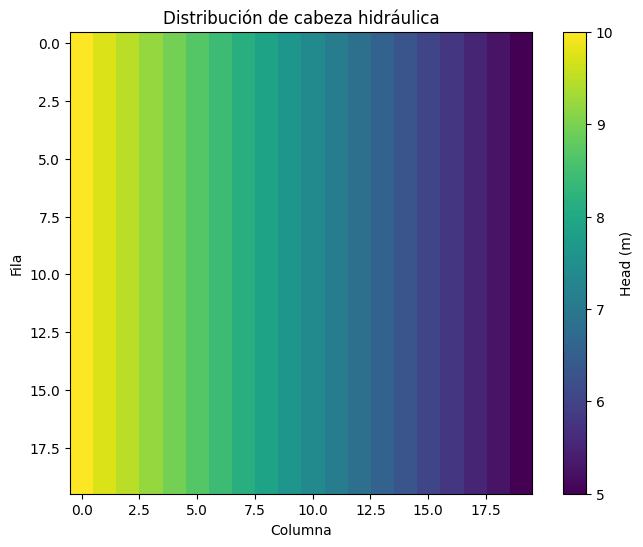

In [9]:
plt.figure(figsize=(8, 6))
plt.imshow(head, cmap="viridis", origin="upper")
plt.colorbar(label="Head (m)")
plt.title("Distribución de cabeza hidráulica")
plt.xlabel("Columna")
plt.ylabel("Fila")
plt.show()

# Referencias

[1] Langevin, C.D., Hughes, J.D., Provost, A.M., Banta, E.R., Niswonger, R.G., and Panday, Sorab, 2017, Documentation for the MODFLOW 6 Groundwater Flow (GWF) Model: U.S. Geological Survey Techniques and Methods, book 6, chap. A55, 197 p., accessed August 4, 2017. https://doi.org/10.3133/tm6A55.

[2] MODFLOW 6 – Description of Input and Output. Version mf6.4.4—February 13, 2024. U.S. Department of the Interior. U.S. Geological Survey.. Archivo: mf6io.pdf de la documentación de MODFLOW 6 que se puede obtener de https://github.com/MODFLOW-ORG/modflow6/releases.